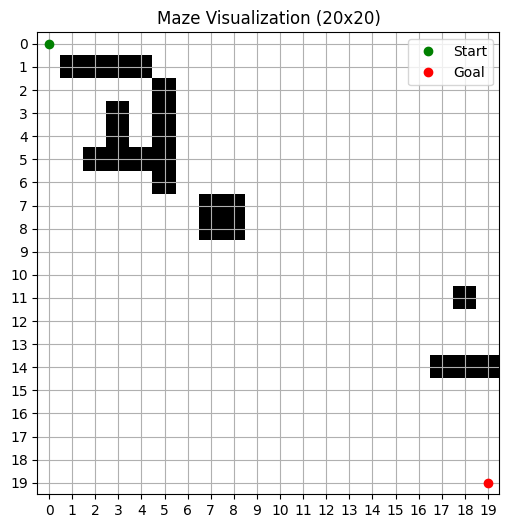

In [1]:
import numpy as np
import matplotlib.pyplot as plt

maze_size = 20 #changed from 10 to 20

maze = np.zeros((maze_size, maze_size), dtype=int)

walls = [
    (1,1),(1,2),(1,3),(1,4),
    (2,5),(3,5),(4,5),(5,5),(6,5),
    (5,2),(5,3),(5,4),
    (3,3),(4,3),
    (7,7),(7,8),(8,7),(8,8),
    (11,18),(14,17),(14,18),(14,19)
]

for r, c in walls:
    maze[r, c] = 1

start = (0, 0)
goal = (maze_size - 1, maze_size - 1)

plt.figure(figsize=(6, 6))
plt.imshow(maze, cmap='binary')

plt.xticks(np.arange(maze_size))
plt.yticks(np.arange(maze_size))
plt.grid(True)

# plot uses (col, row)
plt.plot(start[1], start[0], 'go', label='Start')
plt.plot(goal[1], goal[0], 'ro', label='Goal')

plt.title("Maze Visualization (20x20)")
plt.legend()

plt.show()

# Task2 (BFS Algorithm)

Path found! Length: 39 steps.


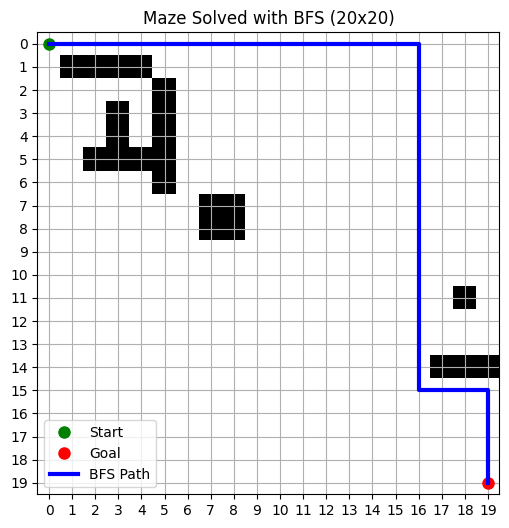

In [2]:
from collections import deque

# --- Task 2: BFS Algorithm ---
def bfs_maze(maze, start, goal):
    rows, cols = maze.shape
    # 4 possible directions: Up, Right, Down, Left
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)] 
    
    # Initialize queue with the start node and its path
    queue = deque([(start, [start])])
    
    # Keep track of visited nodes to avoid infinite loops
    visited = set()
    visited.add(start)
    
    while queue:
        current_node, path = queue.popleft()
        
        # Check if we have reached the goal
        if current_node == goal:
            return path
            
        # Explore all 4 neighbors
        for dr, dc in directions:
            r, c = current_node[0] + dr, current_node[1] + dc
            
            # Check boundaries, walls, and whether it's already visited
            if 0 <= r < rows and 0 <= c < cols and maze[r, c] == 0 and (r, c) not in visited:
                visited.add((r, c))
                queue.append(((r, c), path + [(r, c)]))
                
    # Return None if no path is found
    return None

# Execute BFS and get the path
path = bfs_maze(maze, start, goal)

# --- Plot the Maze and the Path ---
plt.figure(figsize=(6, 6))
plt.imshow(maze, cmap='binary')

plt.xticks(np.arange(maze_size))
plt.yticks(np.arange(maze_size))
plt.grid(True)

# Plot Start and Goal nodes
plt.plot(start[1], start[0], 'go', label='Start', markersize=8)
plt.plot(goal[1], goal[0], 'ro', label='Goal', markersize=8)

# Plot the path if one was found
if path:
    print(f"Path found! Length: {len(path)} steps.")
    path_y = [p[0] for p in path]
    path_x = [p[1] for p in path]
    plt.plot(path_x, path_y, 'b-', linewidth=3, label='BFS Path')
else:
    print("No path found to the goal!")

plt.title("Maze Solved with BFS (20x20)")
plt.legend()
plt.show()
